Ari Mononen \
Elias Rosenberg \
Kim Erwe \
Riku Turunen \
Reng Majer

Kierros 1/10 - Loss: 0.4361
Kierros 2/10 - Loss: 0.3944
Kierros 3/10 - Loss: 0.3665
Kierros 4/10 - Loss: 0.3567
Kierros 5/10 - Loss: 0.3411
Kierros 6/10 - Loss: 0.3318
Kierros 7/10 - Loss: 0.3259
Kierros 8/10 - Loss: 0.3180
Kierros 9/10 - Loss: 0.3107
Kierros 10/10 - Loss: 0.3067


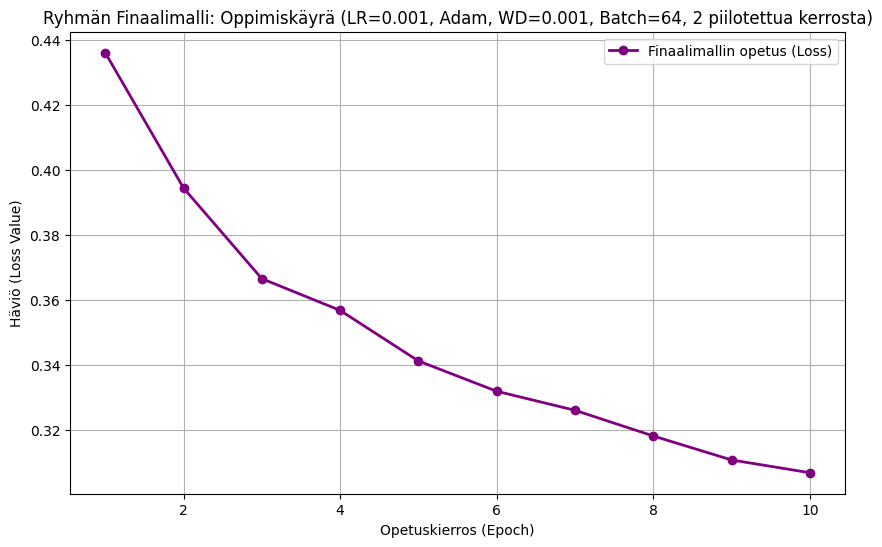

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# 1. Data loading and preparation
# Hint: Use transforms.ToTensor and Normalize
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_dataset, test_dataset = random_split(full_dataset, [50000, 10000])

# ****** RIKUN OSUUS ALKAA *****

best_batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# ****** Rikun osuus loppuu******

# ****** ARIN OSUUS ALKAA ******

# 2. Model definition
# Two hidden layers with ReLU activation functions
class FashionClassifier(nn.Module):
    def __init__(self):
        super(FashionClassifier, self).__init__()
        self.flatten = nn.Flatten() # Flatten layer to convert 2D images to 1D vectors
        self.fc1 = nn.Linear(28*28, 128) # Input layer to hidden layer
        self.fc2 = nn.Linear(128, 64) # Additional hidden layer
        self.fc3 = nn.Linear(64, 10) # Output layer to 10 classes
        self.relu = nn.ReLU() # Activation function
    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

model = FashionClassifier()

# ****** ARIN OSUUS LOPPUU ******

# ****** RENGIN OSUUS ALKAA ******

# We chose 0.001 as the final value. While 0 had lower training loss, 
# 0.001 provides the best balance to prevent overfitting and help 
# the model generalize better on new data.
wd = 0.001 

model = FashionClassifier()
criterion = nn.CrossEntropyLoss()

# Applying the chosen weight decay to the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)

# ****** RENGIN OSUUS LOPPUU ******

# ****** KIMIN OSUUS ALKAA ******

# tehdään koulutusfunktio jotta voidaan ajaa mollemmilla optimizereilla.
def train_with_optimizer(optimizer_name, epochs=5):
    # luodaan uus malli ja weightit nollataan joka kerta
    model = FashionClassifier()
    criterion = nn.CrossEntropyLoss()
    
    # valitaan optimizer param. perusteella.
    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.001)
        
    loss_history = []
    
    #print(f"koulutus optimoijalla: {optimizer_name}")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            optimizer.zero_grad()           
            outputs = model(images)         
            loss = criterion(outputs, labels) 
            loss.backward()                 
            optimizer.step()                
            
            running_loss += loss.item()
            
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        #print(f" koulutuskiekka {epoch+1}/{epochs} - lossi: {avg_loss:.4f}")
        
    return loss_history

# Suoritetaan kokeilut
loss_adam = train_with_optimizer('Adam', epochs=5)
loss_sgd = train_with_optimizer('SGD', epochs=5)

# ****** KIMIN OSUUS LOPPUU ******

# ******* ELIAKSEN OSUUS ALKAA *******


learning_rates = [0.01, 0.001, 0.0001]
all_loss_histories = {} #tallenneteaan hävikki tänne

for lr in learning_rates:
    #print(f"\n=========================================")
    #print(f"Aloitetaan opetus - Learning Rate: {lr}")
    #print(f"=========================================")

    model = FashionClassifier()  # Uusi malli jokaista oppimisnopeutta varten

    #3. Optimization and loss function
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)  # Käytetään Adam-optimointia

    #4. Training loop
    epochs = 5
    loss_history = [] #tallennetaan tämän kierroksen hävikki tähän listaan

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()             # 1. Zero the gradients
            outputs = model(images)           # 2. Forward pass
            loss = criterion(outputs, labels) # 3. Calculate loss
            loss.backward()                   # 4. Backward pass
            optimizer.step()                  # 5. Optimizer step

            running_loss += loss.item()

        # calculate average loss and append to list
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)
        #print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")
        
    # Tallennetaan tämän kierroksen tulokset talteen dictionaryyn
    all_loss_histories[lr] = loss_history

#******* ELIAKSEN OSUUS LOPPUU *******

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=wd)

epochs = 10
loss_history = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        # 1. Zero the gradients (nollataan vanhat gradientit)
        optimizer.zero_grad()
        
        # 2. Forward pass (tehdään ennuste)
        outputs = model(images)
        
        # 3. Calculate loss (lasketaan virhe)
        loss = criterion(outputs, labels)
        
        # 4. Backward pass (lasketaan virheen suunta)
        loss.backward()
        
        # 5. Optimizer step (päivitetään painoja)
        optimizer.step()
        
        running_loss += loss.item()
    
    # Lasketaan kierroksen keskimääräinen häviö ja tallennetaan listaan
    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Kierros {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

# 5. Visualization
plt.figure(figsize=(10, 6))

# Piirretään loss_history. X-akselille tulee automaattisesti numerot 1-10.
plt.plot(range(1, epochs + 1), loss_history, marker='o', color='purple', linewidth=2, label='Finaalimallin opetus (Loss)')

# Otsikot ja selitteet kuntoon
plt.xlabel('Opetuskierros (Epoch)')
plt.ylabel('Häviö (Loss Value)')
plt.title('Ryhmän Finaalimalli: Oppimiskäyrä (LR=0.001, Adam, WD=0.001, Batch=64, 2 piilotettua kerrosta)')
plt.legend()
plt.grid(True)

# Tulostetaan kuvaaja ruudulle
plt.show()

### Elias (Learning rate):

Tutkin oppimisnopeuden (Learning Rate) vaikutusta mallin oppimiseen käyttämällä Adam-optimoijaa. Testasin kolmea eri arvoa: 0.01 (suuri), 0.001 (Adamin oletus) ja 0.0001 (pieni).

LR = 0.001 ( Optimaalinen): Tämä asetus tuotti ylivoimaisesti parhaan tuloksen. Loss-käyrä laskee jyrkästi ja tasaisesti alaspäin koko viiden kierroksen ajan, saavuttaen matalimman häviön (n. 0.30).
Miksi? Askelkoko on täydellisessä tasapainossa: se on riittävän suuri oppiakseen nopeasti, mutta riittävän pieni löytääkseen tarkasti parhaat painoarvot verkolle.

Päätelmä finaalimallia varten:
Ryhmän lopullisessa mallissa suosittelen ehdottomasti käyttämään oppimisnopeutta 0.001, sillä se tarjoaa parhaan ja tehokkaimman oppimiskaaren tälle datalle.


### Riku (Batch size):

DataLoader: Remember, this is efficient for larger datasets
testattiin, mikä batch size on paras. 64 on käytännössä yhtä tarkka, kuin 16, mutta huomattavasti nopeampi.
isompi batch size alkaa menettää tarkkuutta.

### Ari (Network architecture):
Mallin syvyyden lisääminen ei parantanut tarkkuutta, vaan kaikki eri hidden layereiden määrät antoivat lähes samat tulokset. Jos jotakin, niin kolmen layerin malli suoriutui jopa heikommin, eli monimutkaisempi arkkitehtuuri johti lievään ylioppimiseen.

### Kim (Optimizers):

Adam oli nopeampi sekä tehokkaampi kuin SDG.
 
SDG jäi jälkeen jokaisella kierroksella ja sen tehokkuus oli heikompi. Adam saavuttaa suuremman tarkkuuden aiemmin. Kuten kuvaajasta näkee, niin adamin lossikäyrä kulkee selvästi sdg:tä alempana. SDG ei myöskään pystynyt kuromaan viidellä treenikierroksella lossia umpeen, vaan vaatii selvästi enemmän kuin Adam päästäkseen edes lähelle 100% tarkkuutta.

### Reng (Regularization):
Weight decay 0: Tällä parametrilla malli saavutti alhaisimman oppimistappio (training loss) arvon. Riskinä on kuitenkin ylisovitus, jolloin malli oppii datan yksityiskohdat liian tarkasti, suoriutuen huonosti uuden testidatan kanssa.

Weight decay 0.1: Oppimistappio jäi korkeaksi ja oppiminen oli hidasta. Parametri rajoitti mallia liikaa (alisovitus), jolloin se ei kyennyt oppimaan vaatteiden tärkeitä piirteitä.

Weight decay 0.001: Tämä osoittautui parhaaksi arvoksi. Se laskee tappiot tehokkaasti, mutta pakottaa mallin pitämään painokertoimet pieninä, mikä parantaa mallin kykyä yleistää testidataan.